In [2]:
import os
import glob
import ast

import pandas as pd
import numpy as np

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import pprint
from openai import OpenAI

pd.set_option(
    "display.max_colwidth", 12,
    "display.max_rows", 20,
    "display.max_columns", 50,
    "display.precision", 4
)
plt.style.use('./utils/MyStyle.txt')
cm = 1/2.54
palette = ["#3F3517",  '#CE2E31', '#C96F6B', '#CCA464', '#F8D768', '#F0DCD4']

# Parse Data

In [24]:
FOLDER = "./results"
ABSA_COL = "absa_results"
place_col = "place_id"

In [ ]:
# excel_files = glob.glob(os.path.join(FOLDER, "*.xlsx"))

# excel_files = [f for f in excel_files if not os.path.basename(f).startswith("~$")]

# if not excel_files:
#     raise FileNotFoundError(f"No .xlsx files found in folder: {FOLDER}")

# dfs = []
# for f in excel_files:
#     df = pd.read_excel(f)
#     dfs.append(df)

# data = pd.concat(dfs, ignore_index=True)

In [19]:
# data

In [21]:
def parse_absa_cell(value):
    """
    Parse a cell that should contain a list like:
    [
      ('facility_amenities', 'positive'),
      ('natural_environment', 'positive'),
    ]

    Some cells may have extra text before the '['.
    This returns a list of (category, sentiment) tuples.
    """
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    s = str(value)

    # Find first '[' and last ']'
    start = s.find("[")
    end = s.rfind("]")

    if start == -1 or end == -1 or end <= start:
        # Could not find a proper list
        return []

    list_str = s[start:end + 1]

    try:
        parsed = ast.literal_eval(list_str)
    except Exception:
        return []

    # Ensure it is a list of tuples
    if not isinstance(parsed, (list, tuple)):
        return []

    clean_pairs = []
    for item in parsed:
        if isinstance(item, (list, tuple)) and len(item) >= 2:
            category = str(item[0])
            sentiment = str(item[1]).lower().strip()
            clean_pairs.append((category, sentiment))

    return clean_pairs

In [ ]:
data.to_csv('all_absa_results.csv', index=False)

In [ ]:
# data = pd.read_csv("all_absa_results.csv")

In [25]:
rows = []

for idx, row in data.iterrows():
    place = row[place_col]
    pairs = parse_absa_cell(row.get(ABSA_COL, None))

    for category, sentiment in pairs:
        rows.append(
            {
                "place": place,
                "category": category,
                "sentiment": sentiment,
            }
        )

absa_long = pd.DataFrame(rows)

if absa_long.empty:
    raise ValueError("No valid ABSA pairs were parsed from the absa_results column.")


In [29]:
data[data.absa_results=='[]']

,place_id,author,place_name_y,date_parsed,text,ind,absa_results
2218,ChIJn97J...,Yasser T...,Melbourn...,2025-07-12,We reall...,1004,[]
2801,ChIJXwva...,Lyen Rou...,Barron F...,2025-05-13,Was real...,373,[]
2810,ChIJXwva...,Behzad,Barron F...,2022-10-11,One of t...,382,[]
2866,ChIJXwva...,Jasmine ...,Barron F...,2025-05-13,Breathta...,438,[]
2874,ChIJXwva...,Christop...,Barron F...,2025-05-13,👍 …,446,[]
...,...,...,...,...,...,...,...
5931443,ChIJ9W8H...,J i l l,HOYTS Vi...,2025-09-10,Not too ...,613,[]
5931481,ChIJ9W8H...,ういあきひろ,HOYTS Vi...,2025-09-10,Good🍿 …,651,[]
5931707,ChIJ9W8H...,Michael,HOYTS Vi...,2020-10-11,Absolute...,877,[]
5931751,ChIJ9W8H...,Cecilia ...,HOYTS Vi...,2023-10-11,Cool 3D,921,[]


In [21]:
valid_sentiments = ["positive", "negative", "neutral"]
absa_long = absa_long[absa_long["sentiment"].str.strip().isin(valid_sentiments)]

counts = (
    absa_long
    .groupby(["place", "category", "sentiment"])
    .size()
    .unstack("sentiment", fill_value=0)
)

# Ensure all three columns exist
for s in valid_sentiments:
    if s not in counts.columns:
        counts[s] = 0

# Reorder columns
counts = counts[["positive", "negative", "neutral"]]

In [22]:
counts

sentiment                                            positive  negative  \
place                       category                                      
ChIJ---x8qdH1moR6D9JnKM5jNk activities_events              10         0   
                            atmosphere_vibe                 2         0   
                            cleanliness_maintenance         1         0   
                            facilities_amenities            8         1   
                            inclusivity_community           2         0   
...                                                       ...       ...   
ChIJzzxTMGjHEmsRT9ln5B70WnE other                           0         0   
                            overall_experience             26         3   
                            pricing_value                  24         2   
                            service_process                11         2   
                            staff_attitude                 35         2   

sentiment                                            neutral  
place                       category                          
ChIJ---x8qdH1moR6D9JnKM5jNk activities_events              0  
                            atmosphere_vibe                0  
                            cleanliness_maintenance        0  
                            facilities_amenities           0  
                            inclusivity_community          0  
...                                                      ...  
ChIJzzxTMGjHEmsRT9ln5B70WnE other                          1  
                            overall_experience             0  
                            pricing_value                  1  
                            service_process                3  
                            staff_attitude                 0  

[986559 rows x 3 columns]

In [ ]:
counts["total"] = counts["positive"] + counts["negative"] + counts["neutral"]

# Avoid division by zero
counts["score"] = np.where(
    counts["total"] > 0,
    (counts["positive"] - counts["negative"]) / counts["total"],
    0,
)

quality_index = counts.reset_index()

In [24]:
quality_index

sentiment,place,category,positive,negative,neutral,total,score
0,ChIJ---x8qdH1moR6D9JnKM5jNk,activities_events,10,0,0,10,1.000000
1,ChIJ---x8qdH1moR6D9JnKM5jNk,atmosphere_vibe,2,0,0,2,1.000000
2,ChIJ---x8qdH1moR6D9JnKM5jNk,cleanliness_maintenance,1,0,0,1,1.000000
3,ChIJ---x8qdH1moR6D9JnKM5jNk,facilities_amenities,8,1,0,9,0.777778
4,ChIJ---x8qdH1moR6D9JnKM5jNk,inclusivity_community,2,0,0,2,1.000000
...,...,...,...,...,...,...,...
986554,ChIJzzxTMGjHEmsRT9ln5B70WnE,other,0,0,1,1,0.000000
986555,ChIJzzxTMGjHEmsRT9ln5B70WnE,overall_experience,26,3,0,29,0.793103
986556,ChIJzzxTMGjHEmsRT9ln5B70WnE,pricing_value,24,2,1,27,0.814815
986557,ChIJzzxTMGjHEmsRT9ln5B70WnE,service_process,11,2,3,16,0.562500


## Quality Index

In [4]:
quality_index = pd.read_excel("quality_index_by_place_category.xlsx")

In [5]:
# categories = pd.DataFrame(quality_index["category"].unique(), columns=["category"])
# categories

In [ ]:
# import dspy
# from typing_extensions import Any, Dict, List, TypedDict, Literal, Annotated, Optional, Tuple
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from tqdm.auto import tqdm

# class ABSA_Signature(dspy.Signature):
#     """
#     For the given aspect, assign one category from the list below to the aspect:
#     staff_attitude, service_process, food_drink, pricing_value, location_access, facilities_amenities, cleanliness_maintenance, atmosphere_vibe, natural_environment, activities_events, safety_security, policies_governance, inclusivity_community, overall_experience, other.
#     """
#     aspect: str = dspy.InputField(desc='The aspect of the place.')

#     category: Literal['staff_attitude', 'service_process', 'food_drink', 'pricing_value', 'location_access', 'facilities_amenities', 'cleanliness_maintenance', 'atmosphere_vibe', 'natural_environment', 'activities_events', 'safety_security', 'policies_governance', 'inclusivity_community', 'overall_experience', 'other'] = dspy.OutputField(
#         desc="One category from the category list"
#     )


# GPT_MODEL = 'openai/gpt-4.1-mini'


# lm = dspy.LM(GPT_MODEL, api_key=GPT_API_KEY, temperature=1.0, max_tokens=16000)
# dspy.configure(lm=lm)

# ABSA = dspy.Predict(ABSA_Signature)
# print(ABSA(aspect="staff_attitude").category)

# def return_category(aspect):
#     return ABSA(aspect=aspect).category


# unique_words = categories['category'].dropna().unique()
# word_to_cat = {}
# print('Start mapping categories!')

# with ThreadPoolExecutor(max_workers=5) as executor:
#     print('Mapping categories...')
#     future_to_word = {executor.submit(return_category, w): w for w in unique_words}

#     print('Still mapping categories...')
#     for future in tqdm(as_completed(future_to_word), total=len(future_to_word)):
#         w = future_to_word[future]
#         cat = future.result()
#         word_to_cat[w] = cat
#     print('Done!')

# categories["assigned_category"] = categories["category"].map(word_to_cat)
# categories.to_excel("categories_mapper.xlsx", index=False)
# print(categories[["category", "assigned_category"]].head())

In [ ]:
# quality_index.to_excel("quality_index_by_place_category.xlsx", index=False)
# print("Saved quality_index_by_place_category.xlsx")

Saved quality_index_by_place_category.xlsx


In [6]:
quality_index.head()

,place,category,positive,negative,neutral,total,score,assigned_category,max_similarity
0,ChIJ---x...,activiti...,10,0,0,10,1.0000,activiti...,1.0
1,ChIJ---x...,atmosphe...,2,0,0,2,1.0000,atmosphe...,1.0
2,ChIJ---x...,cleanlin...,1,0,0,1,1.0000,cleanlin...,1.0
3,ChIJ---x...,faciliti...,8,1,0,9,0.7778,faciliti...,1.0
4,ChIJ---x...,inclusiv...,2,0,0,2,1.0000,inclusiv...,1.0


In [17]:
quality_index.neutral.sum()

np.int64(1046332)

In [18]:
15787076  / 8151805

1.9366356285509774

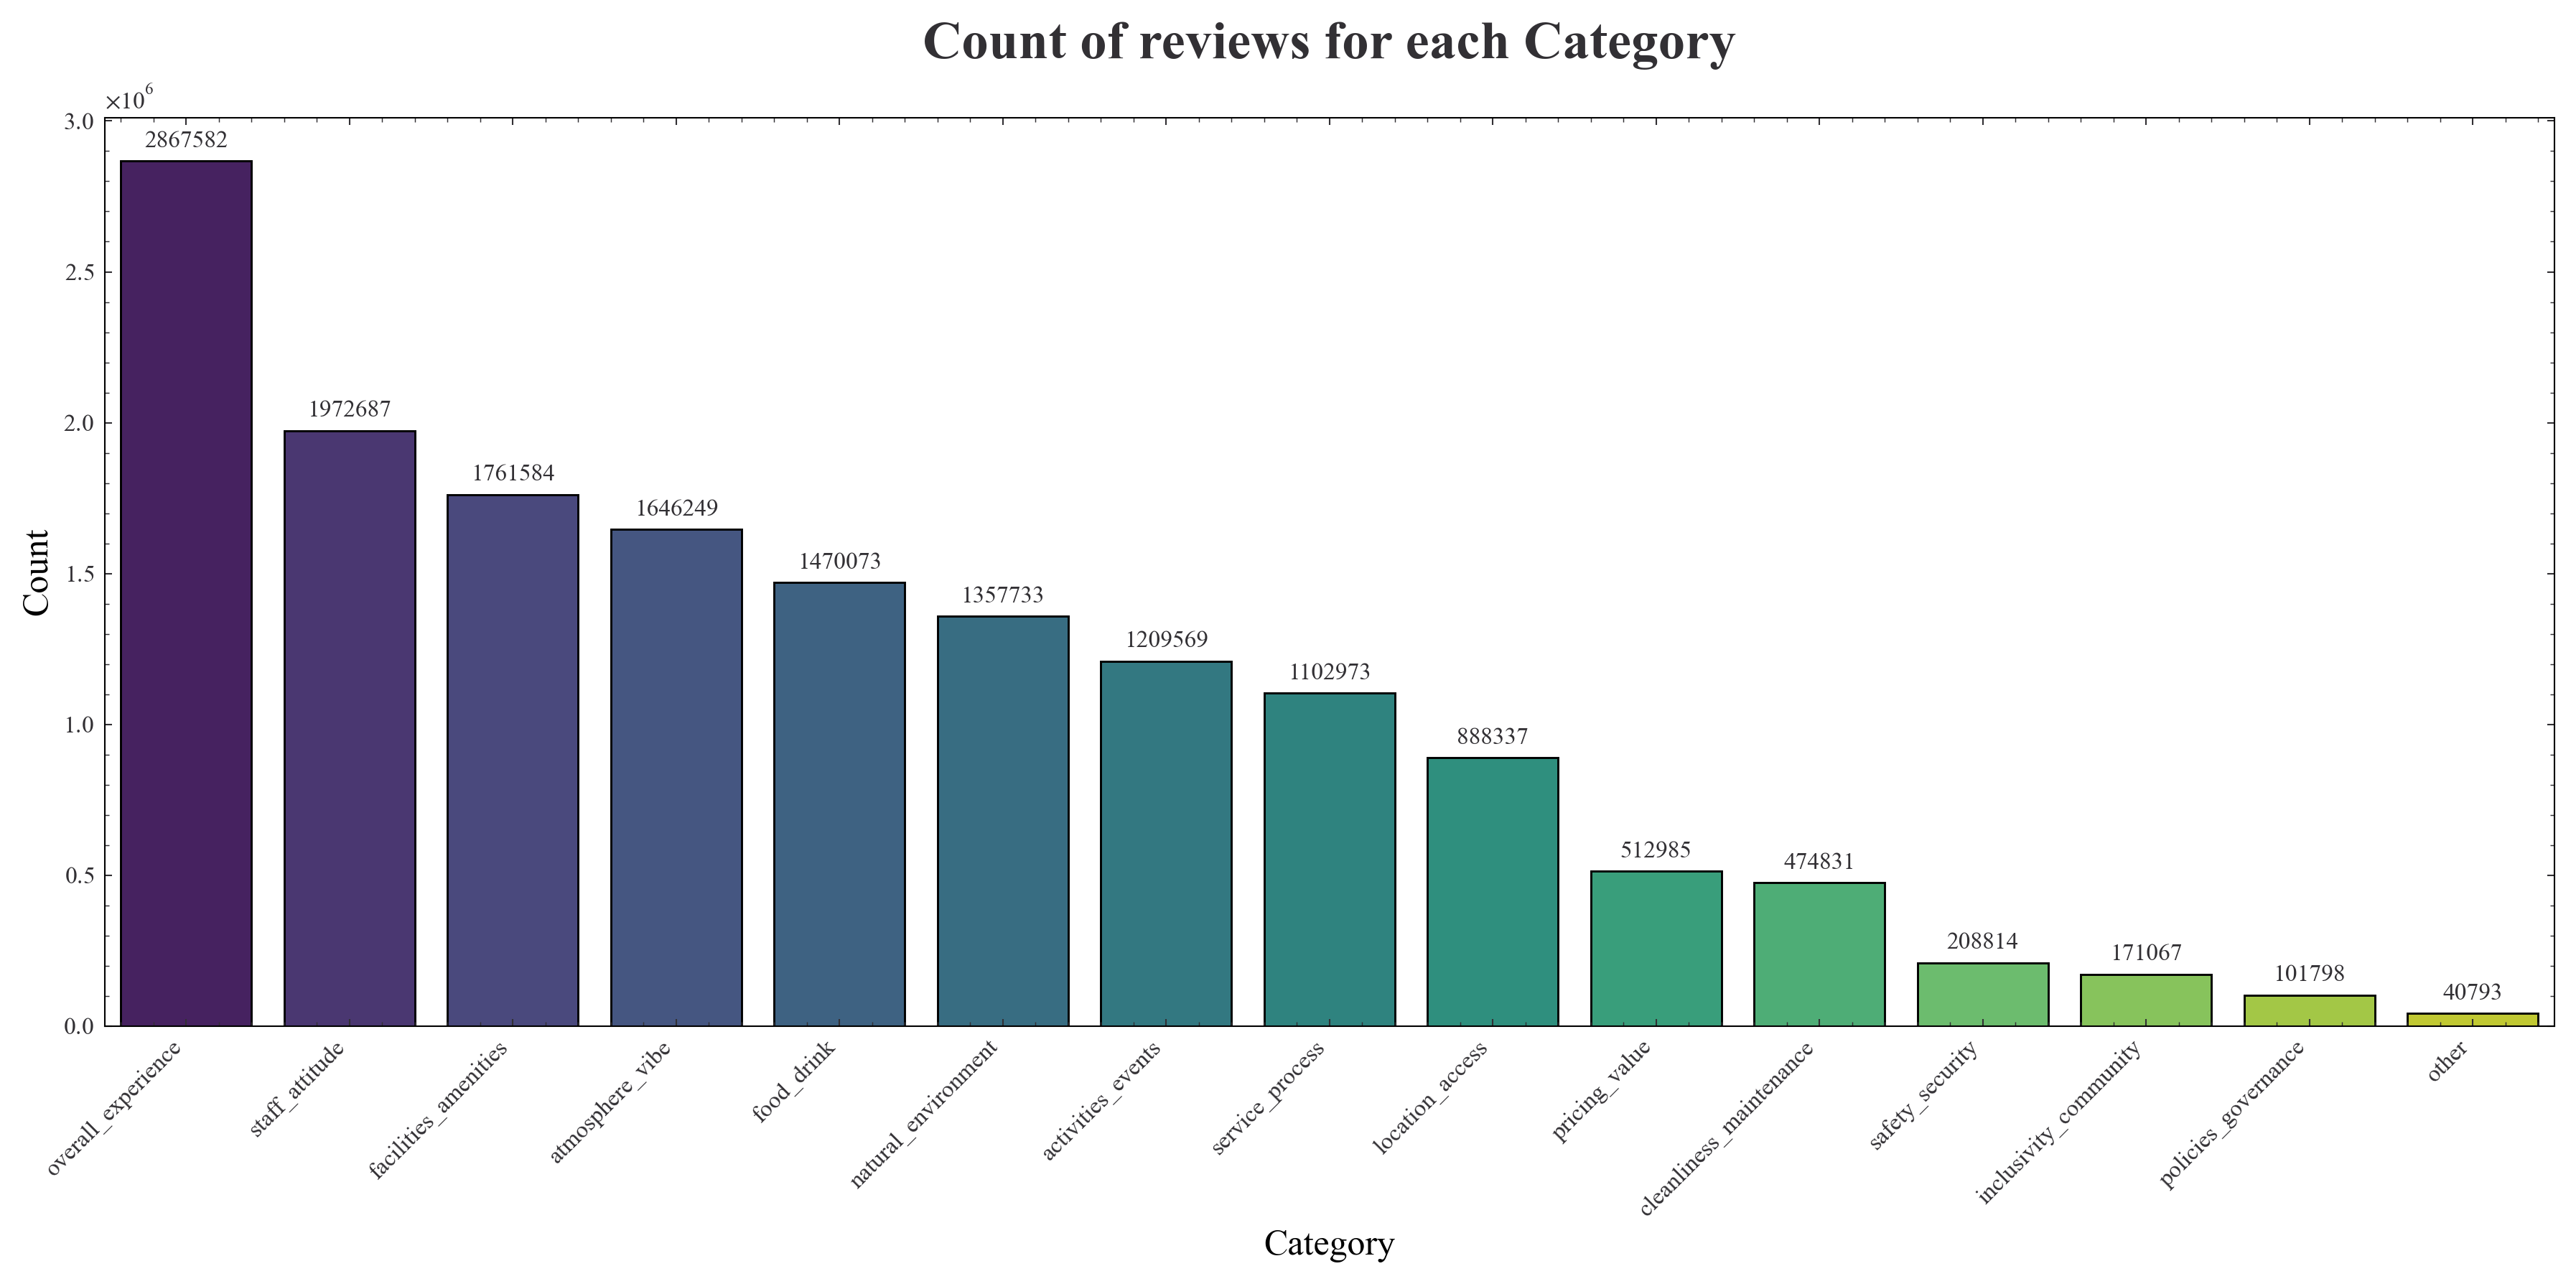

In [12]:
import seaborn as sns

plot_data = quality_index.groupby('assigned_category').agg({'total': 'sum'}).reset_index()
plot_data = plot_data.sort_values('total', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_data,
    x='assigned_category',
    y='total',
    palette='viridis',
    hue='assigned_category',
    legend=False
)
# sns.despine(left=True) # Remove left/top/right borders
ax.set_title('Count of reviews for each Category', fontsize=18, pad=20, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
# Rotate x-labels if needed
plt.xticks(rotation=45, ha='right')
# Add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%d') # Use fmt='%.2f' if floats
plt.tight_layout()
plt.show()

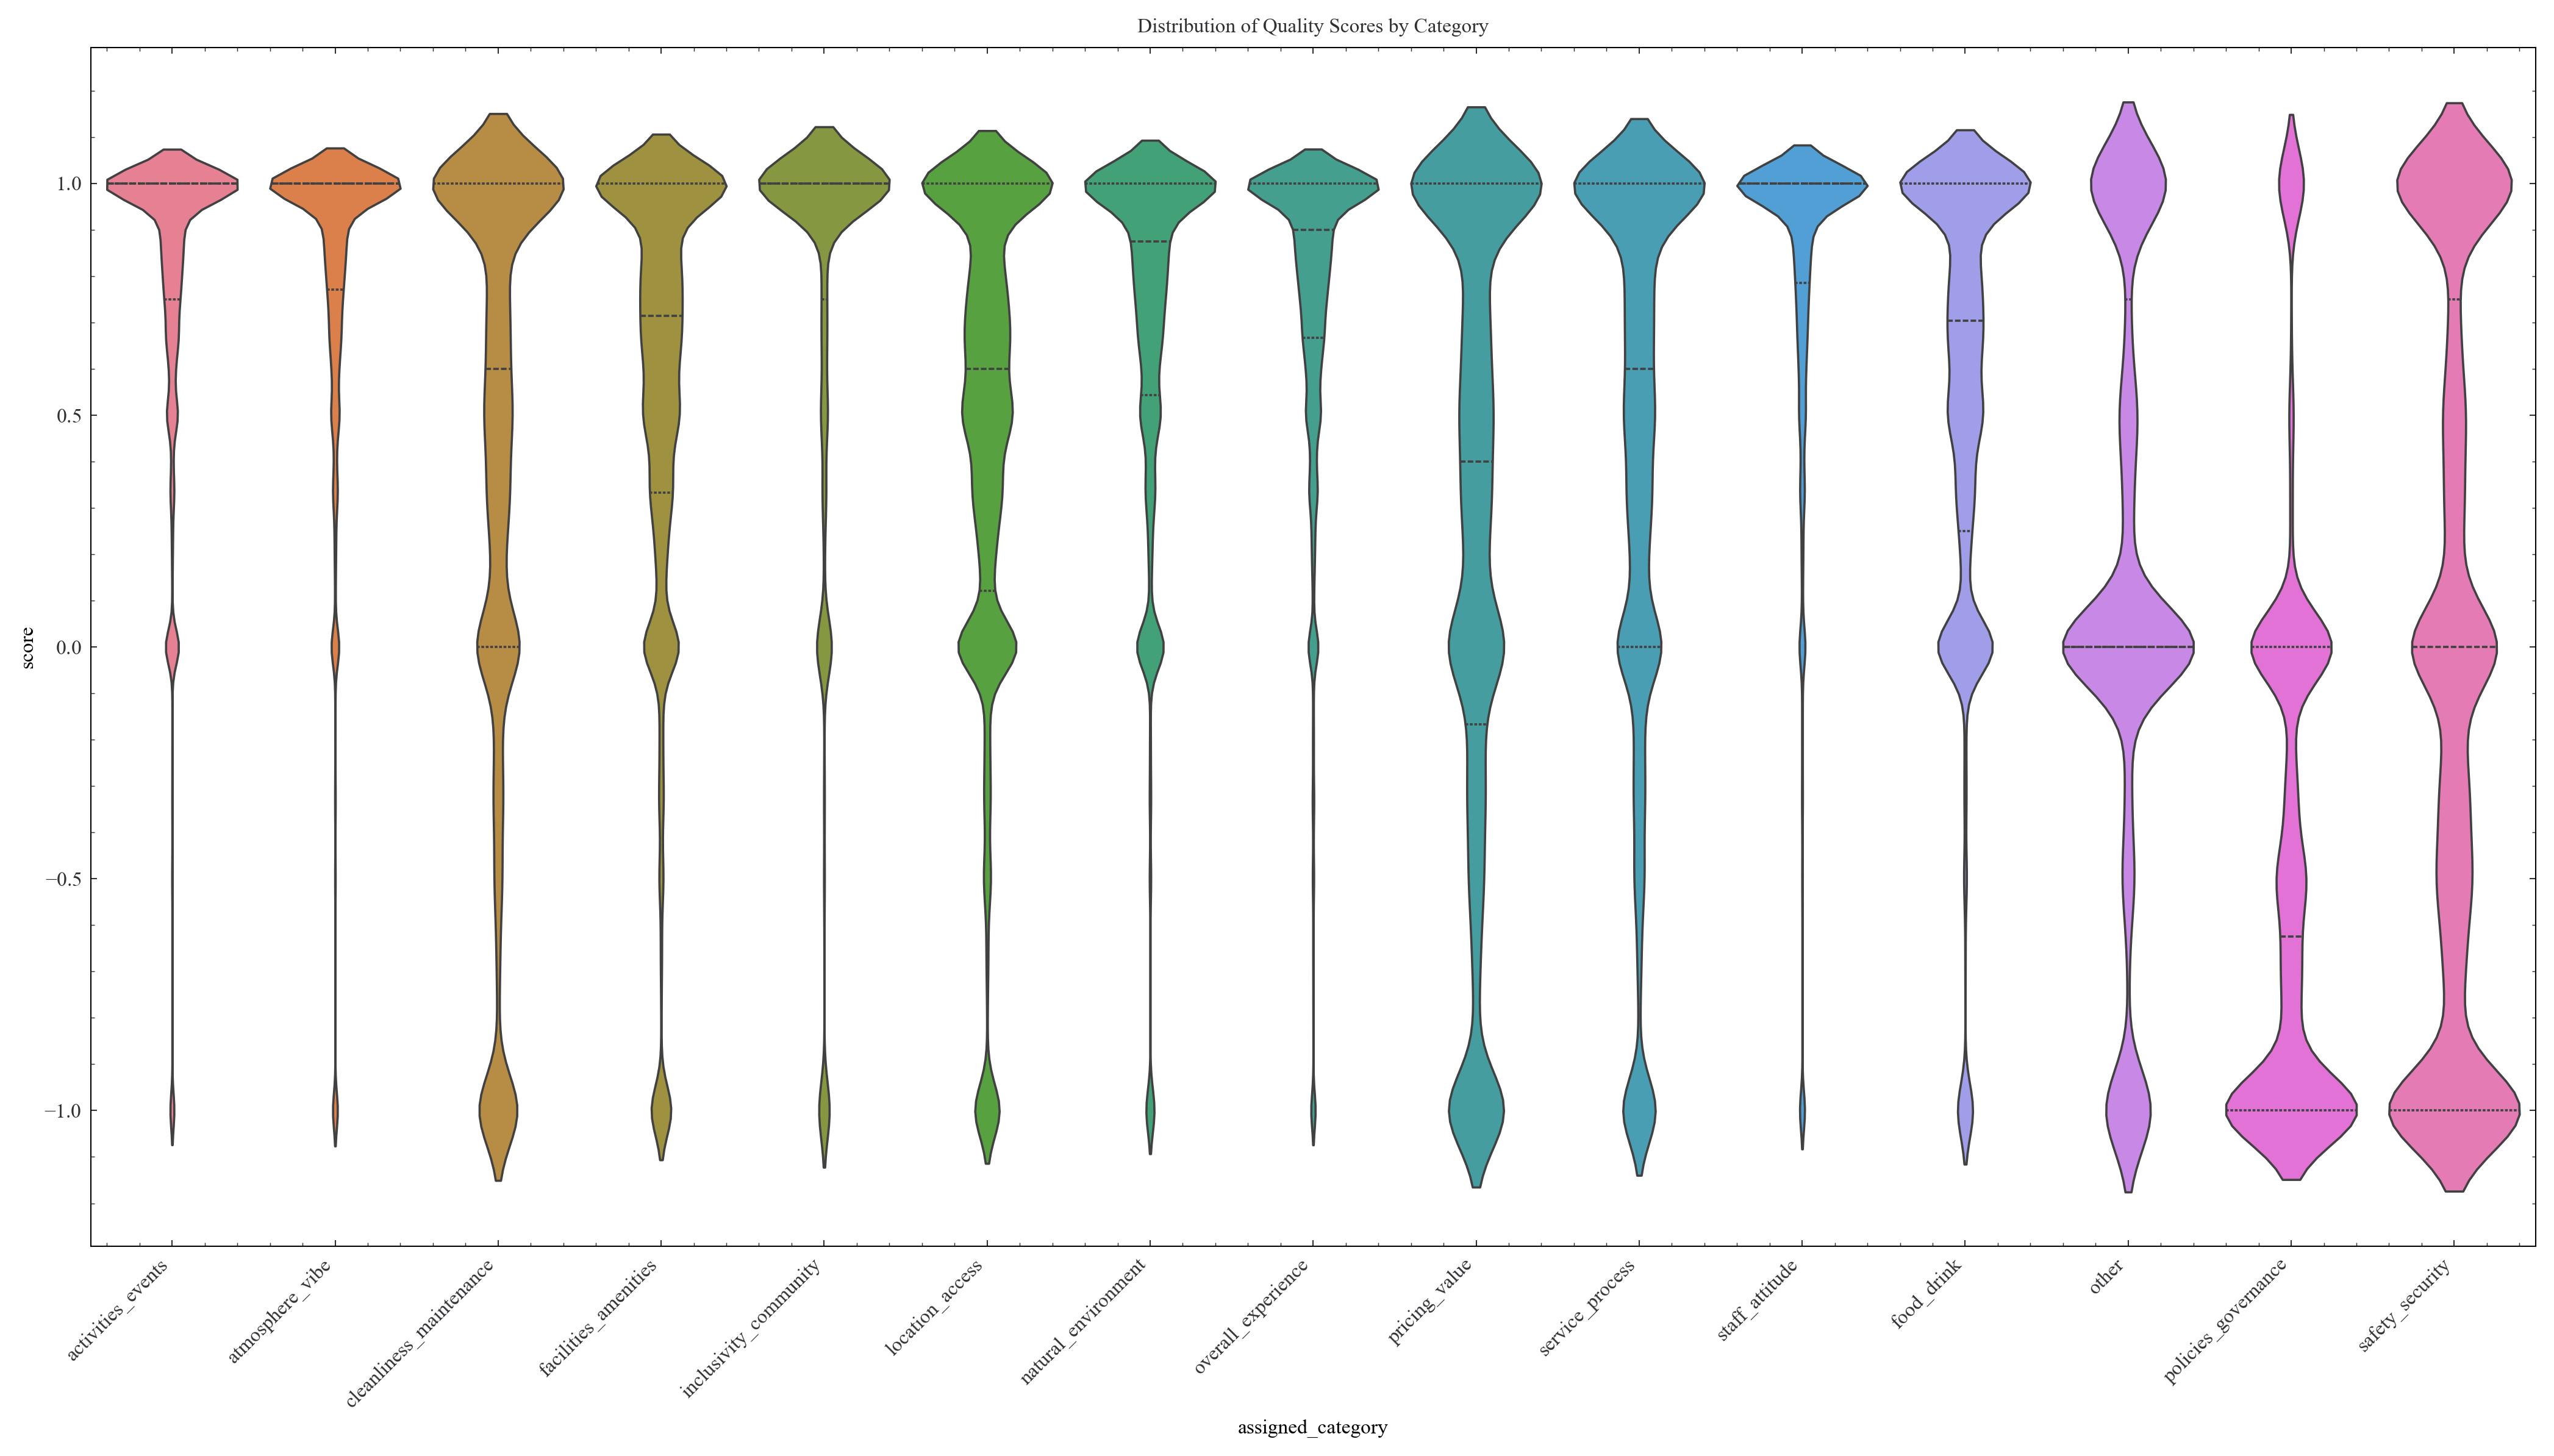

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.violinplot(
    data=quality_index,
    x="assigned_category",
    y="score",
    hue="assigned_category",
    inner="quart",
    # split=True,
    palette="husl"
)

plt.xticks(rotation=45, ha="right")
plt.legend().remove()
plt.title("Distribution of Quality Scores by Category")
plt.tight_layout()
plt.show()

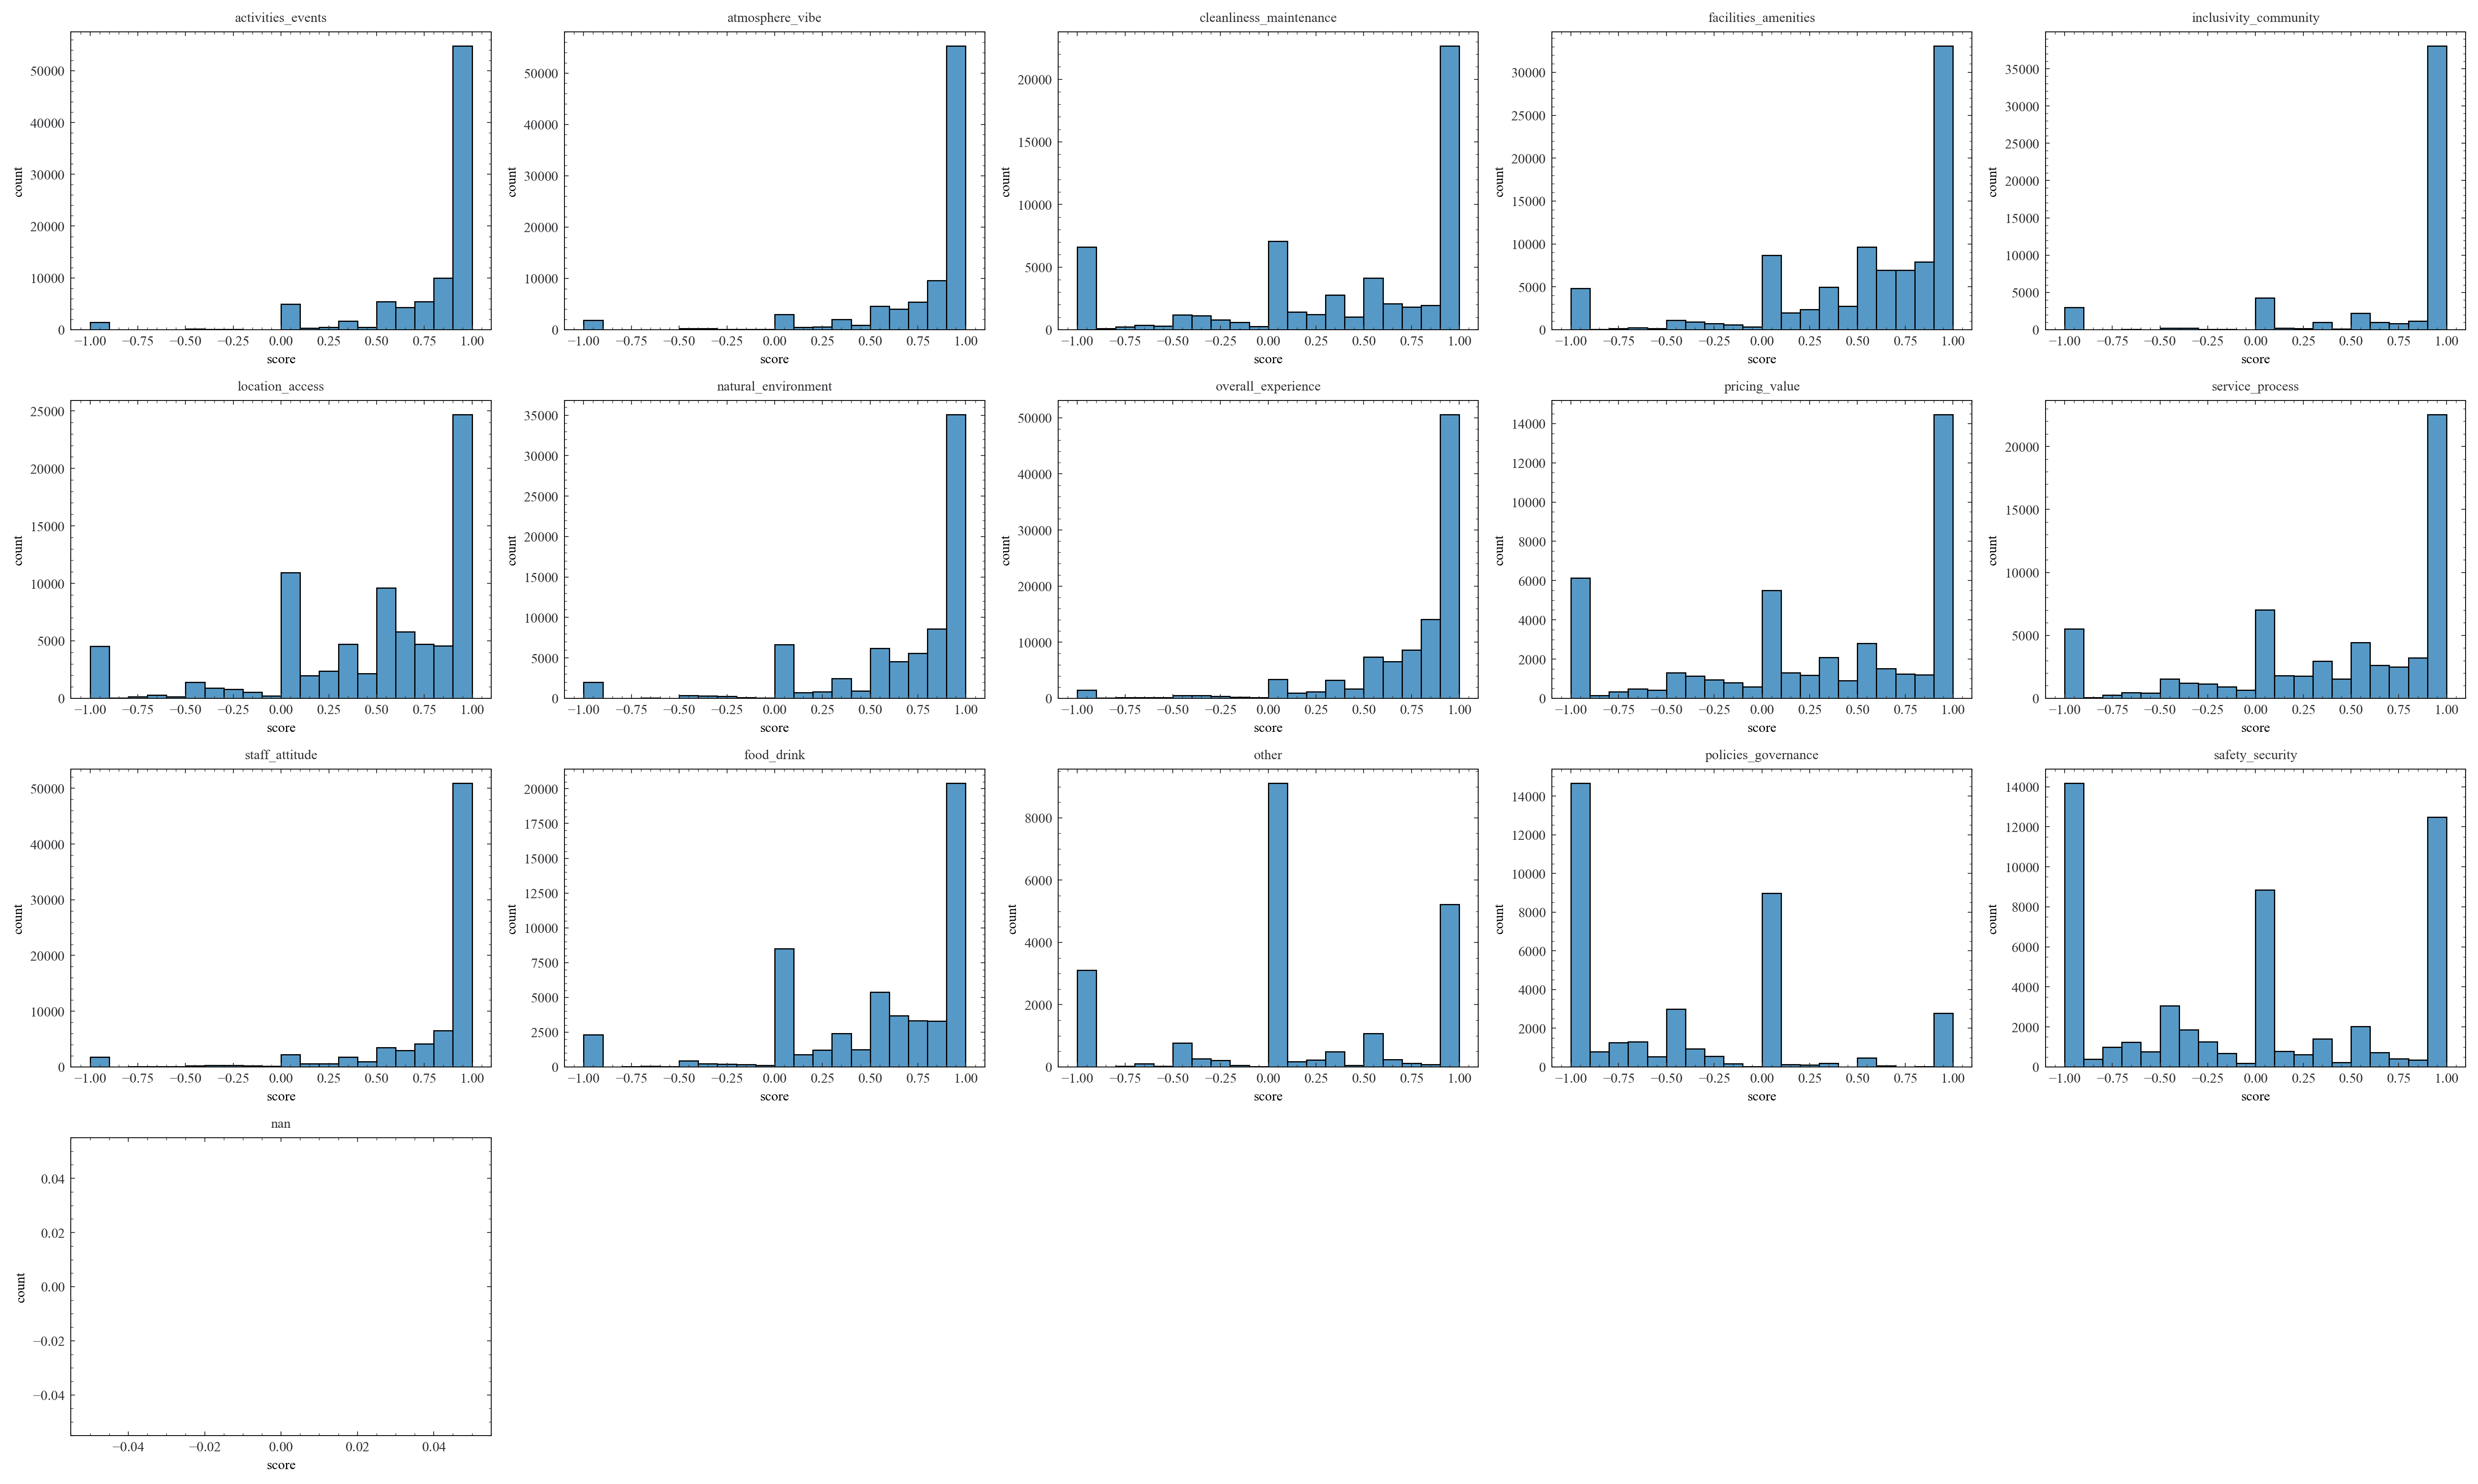

In [25]:
df = quality_index   # your dataframe
CAT_COL = "assigned_category"
SCORE_COL = "score"

categories = df[CAT_COL].unique()
n_cat = len(categories)

# Choose subplot grid size
n_cols = 5
n_rows = int(np.ceil(n_cat / n_cols))

plt.figure(figsize=(4*n_cols, 3*n_rows))

for i, cat in enumerate(categories, 1):
    plt.subplot(n_rows, n_cols, i)
    
    sub = df[df[CAT_COL] == cat]
    
    sns.histplot(sub[SCORE_COL], bins=20, kde=False)
    
    plt.title(cat)
    plt.xlabel("score")
    plt.ylabel("count")

plt.tight_layout()
plt.show()

In [26]:
counts["weight"] = np.log(1.0 + counts["total"])

counts_reset = counts.reset_index()  # place, category as columns

def compute_qi(group):
    # group is all rows for one place (different categories)
    w = group["weight"]
    s = group["score"]
    if w.sum() == 0:
        return 0
    return (w * s).sum() / w.sum()

quality_by_place = (
    counts_reset
    .groupby("place")
    .apply(compute_qi)
    .reset_index(name="quality_index")
)

C:\Users\asus\AppData\Local\Temp\ipykernel_25520\2170100287.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_qi)


In [27]:
quality_by_place

,place,quality_index
0,ChIJ---x8qdH1moR6D9JnKM5jNk,0.925854
1,ChIJ--2e0PUFkWsR9Fo4gpMdTKs,0.406072
2,ChIJ--3OW0FudGsRM5oZSJTO6Ys,0.909290
3,ChIJ--5XAgDr62sRQ_98lAOXCa0,0.854597
4,ChIJ--6yq5HZsGoRRCkfojXeaB0,0.446220
...,...,...
103387,ChIJzzs6HMhFuWoRzgGip45pQjM,0.750000
103388,ChIJzzsxTNfRsGoR4qxcFImR5lo,0.447906
103389,ChIJzztFbyA71moRj65ua3iPxkQ,0.786456
103390,ChIJzzx0XQB1MCoRgdLk6HhL9Qw,-0.105639


In [28]:
df_places = pd.read_excel('../../places/all_places_australia_sa1.xlsx')

df_places.shape

(247413, 52)

In [33]:
df_index = df_places.merge(quality_by_place, left_on='id', right_on='place', how='inner')
df_index.shape

(103392, 54)

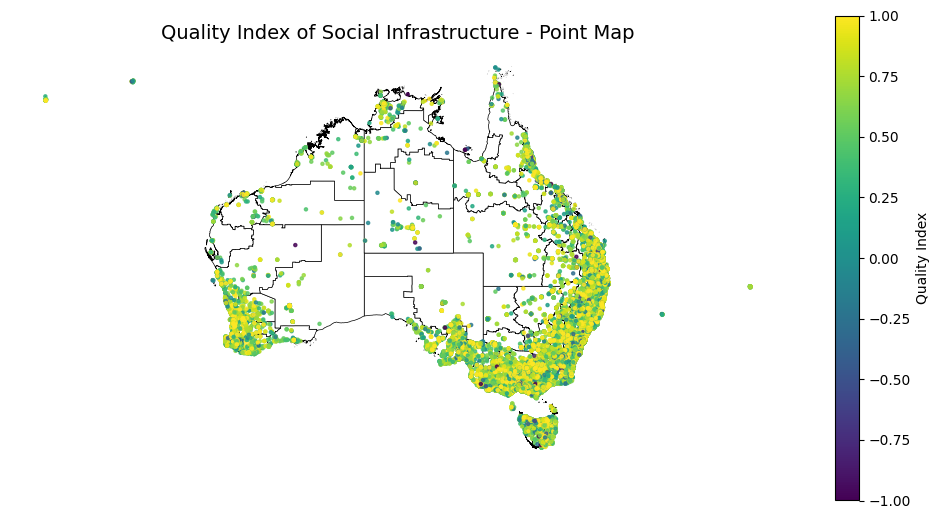

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


LAT_COL = "latitude"
LON_COL = "longitude"


gdf = gpd.GeoDataFrame(
    df_index,
    geometry=gpd.points_from_xy(df_index[LON_COL], df_index[LAT_COL]),
    crs="EPSG:4326"
)

australia = gpd.read_file("../../shapes/SA3_SHP/SA3_2021_AUST_GDA2020.shp")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

australia.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)

# Plot places, colored by quality_index
gdf.plot(
    column="quality_index",
    ax=ax,
    legend=True,
    cmap="viridis",
    markersize=5,
    alpha=0.8,
    legend_kwds={
        "shrink": 0.4,
        "label": "Quality Index"
    },
)

ax.set_title("Quality Index of Social Infrastructure - Point Map", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
# plt.savefig("australia_quality_points.png", dpi=300)
plt.show()


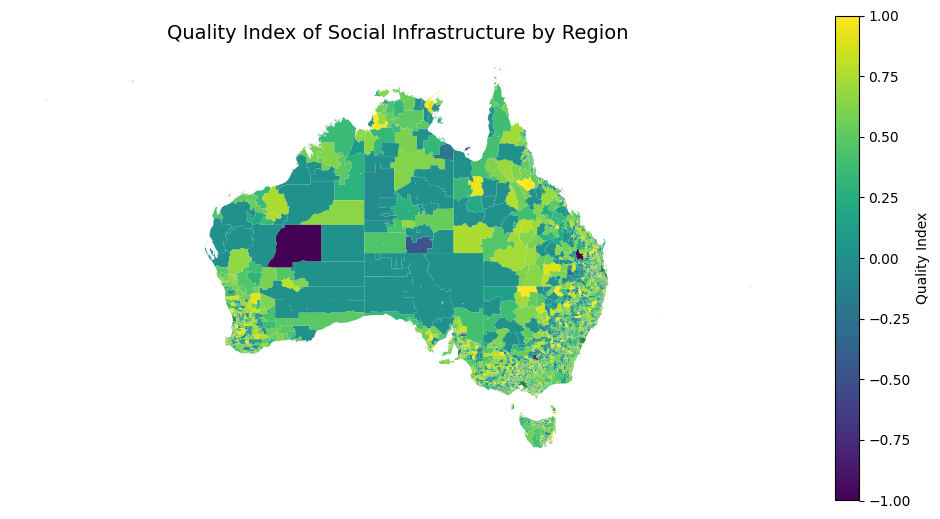

In [ ]:
df_avg_quality = df_index.groupby('SA1_CODE21_left').agg({'quality_index': 'mean'}).reset_index()
df_avg_quality.SA1_CODE21_left = df_avg_quality.SA1_CODE21_left.astype(str)

australia_sa1 = gpd.read_file("../../shapes/SA1_SHP/SA1_2021_AUST_GDA2020.shp")
australia_sa1.SA1_CODE21 = australia_sa1.SA1_CODE21.astype(str)

australia_sa1 = australia_sa1.merge(df_avg_quality, left_on='SA1_CODE21', right_on='SA1_CODE21_left', how='left')
australia_sa1["quality_index"] = australia_sa1["quality_index"].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


# australia_sa1.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)


australia_sa1.plot(
    column="quality_index",
    ax=ax,
    legend=True,
    cmap="viridis",
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "No data"
    },
    legend_kwds={
        "shrink": 0.4,
        "label": "Quality Index"
    },
)

ax.set_title("Quality Index of Social Infrastructure by Region", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("australia_quality_heatmap.png", dpi=300)
plt.show()